# CG3201 Project  3:  Residual  Networks  with  Different  Residual Block Types for Image Classification
by Kenneth Wong Cun Wi A0303203A

# Part 1: Data Loading and Preprocessing
Points to note:
- We use seed = 203 as part of our randomisation for choosing 25 classes out of the 200 in the Tiny-ImageNet-200 dataset.

- The dataset has split training, validation and test images. Upon inspection, it has a file structure that requires a script to identify and retrieve the samples manually: Tiny-ImageNet validation has images in one folder plus labels in a separate annotation file, so ImageFolder cannot directly infer labels there. 

- Validation set is labeled but test set is not. Trying to match val and test imageswith the same file name number (e.g. val_0.JPEG -> test_0.JPEG) shows they belong to different classes. Hence, we will treat test foldersplit as unlabeled inference-only data and simply load all of them. For subsequent parts, we only report training/validation metric for evaluation.

- It is given that the data's distribution is perfectly even (200 classes; 100,000 training images (500 per class); 10,000 validation images (50 per class); 10,000 test images (50 per class)). Hence, there is no need for a WeightedRandomSampler.

SEED:  203
Selected class count: 25
Selected class ID | WNID | Class name
  6 | n01742172 | boa constrictor, Constrictor constrictor
  8 | n01770393 | scorpion
 11 | n01784675 | centipede
 24 | n02074367 | dugong, Dugong dugon
 25 | n02085620 | Chihuahua
 27 | n02099601 | golden retriever
 31 | n02123045 | tabby, tabby cat
 34 | n02125311 | cougar, puma, catamount, mountain lion, painter, panther, Felis concolor
 55 | n02480495 | orangutan, orang, orangutang, Pongo pygmaeus
 61 | n02669723 | academic gown, academic robe, judge's robe
 64 | n02769748 | backpack, back pack, knapsack, packsack, rucksack, haversack
 67 | n02793495 | barn
 89 | n02999410 | chain
 90 | n03014705 | chest
 98 | n03179701 | desk
126 | n03838899 | oboe, hautboy, hautbois
143 | n04099969 | rocking chair, rocker
147 | n04149813 | scoreboard
151 | n04259630 | sombrero
153 | n04275548 | spider web, spider's web
154 | n04285008 | sports car, sport car
157 | n04356056 | sunglasses, dark glasses, shades
165 | n04465501

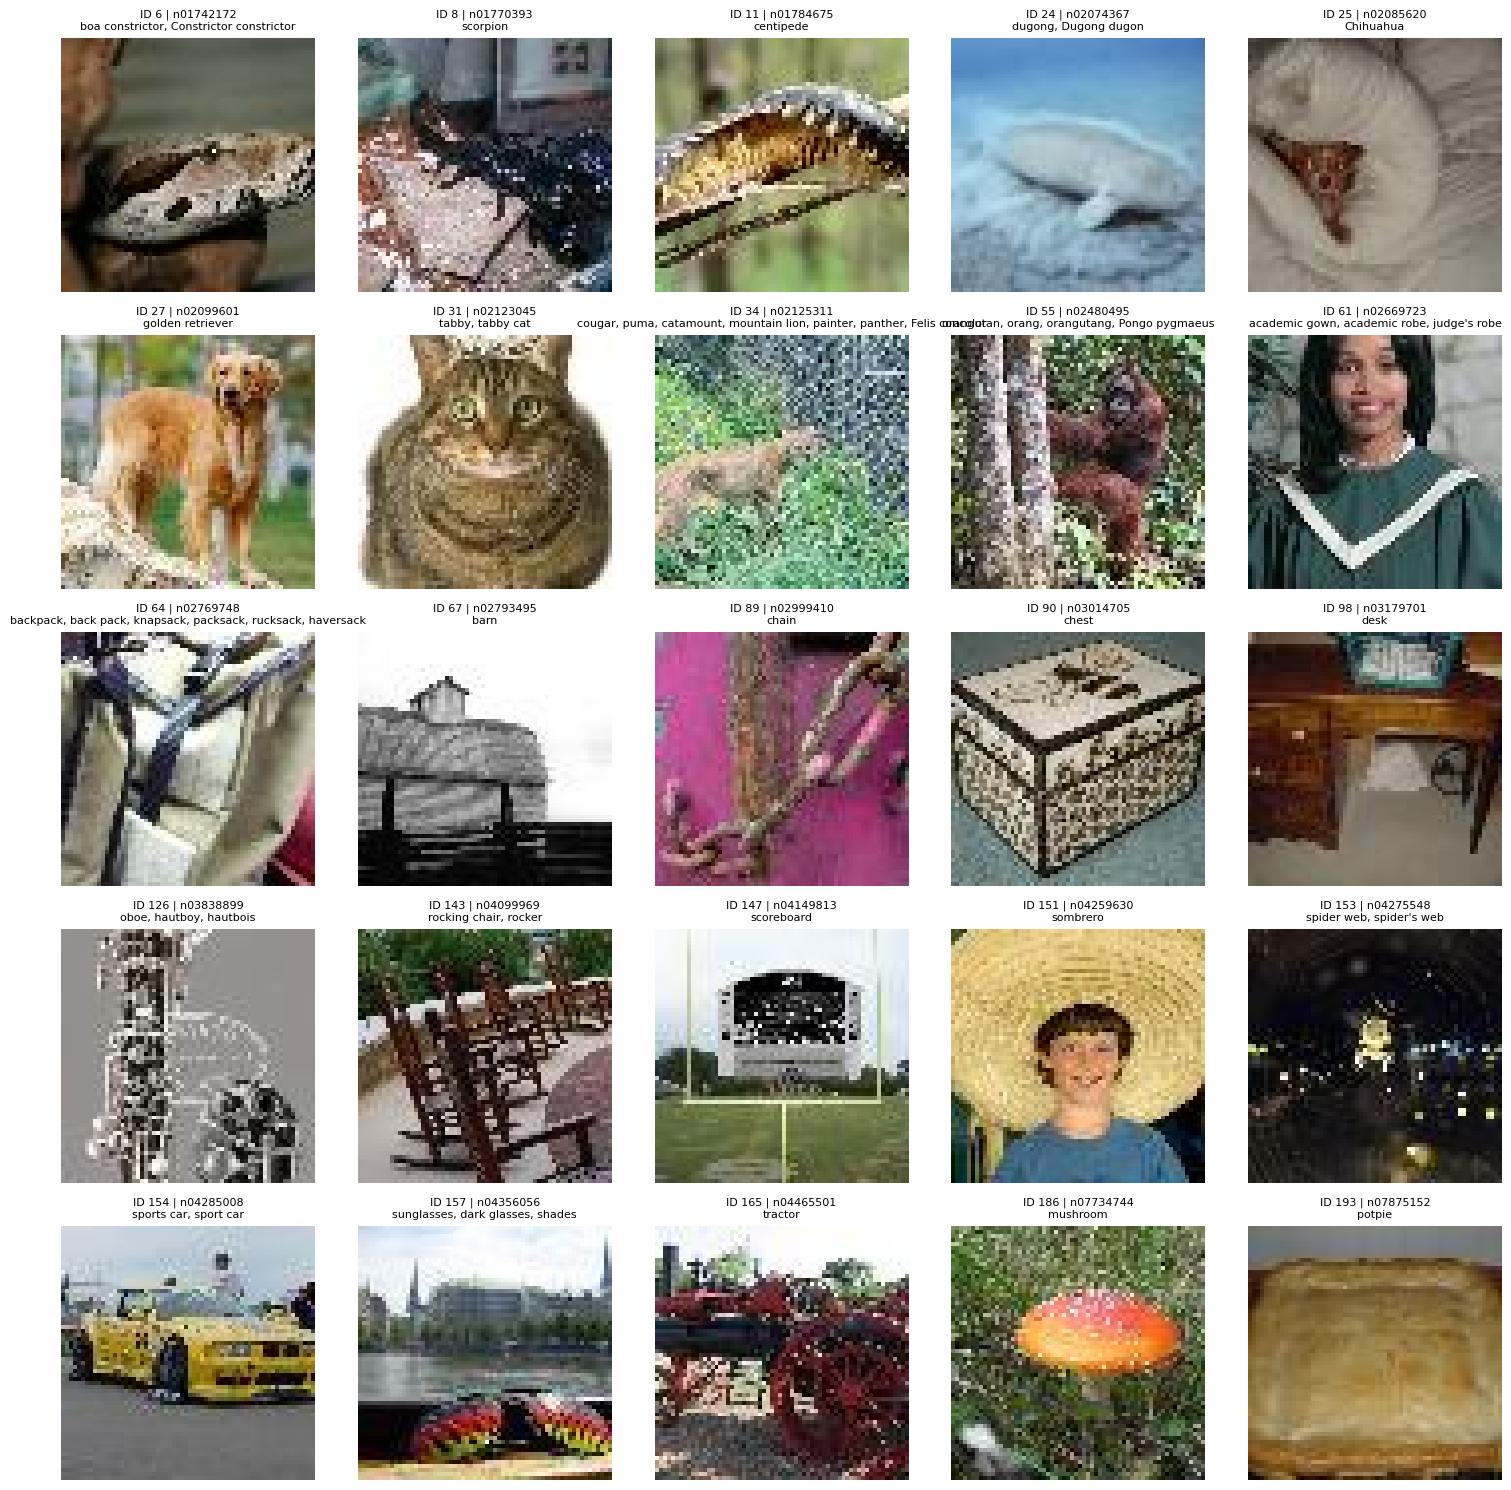

In [ ]:
import os
import random
from collections import defaultdict

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

# Fix seed and cuda for training on kaggle for gpu
SEED = 203
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print ("SEED: ", SEED)

# No. of imaages processed at once for faster training, depends on GPU memory
BATCH_SIZE = 128

'''
Data acquisition and preparation for collection of samples
'''
DATA_FOLDER = "/kaggle/input/datasets/nikhilshingadiya/tinyimagenet200/tiny-imagenet-200"
TRAIN_DATA_FOLDER = os.path.join(DATA_FOLDER, "train")
VAL_DATA_FOLDER = os.path.join(DATA_FOLDER, "val")
TEST_DATA_FOLDER = os.path.join(DATA_FOLDER, "test")
    
# Obtain the 25 random numbers from 1..200
selected_class_ids = sorted(random.sample(range(1, 201), 25)) 

# Read all folder IDs == class names in train (and ensure sorted ['n01443537', 'n01629819', ...]))
all_folder_ids = sorted([d for d in os.listdir(TRAIN_DATA_FOLDER) 
                         if os.path.isdir(os.path.join(TRAIN_DATA_FOLDER, d))]) 

# Identify the folders IDs corresponding to the sampled 1-based indices
selected_folder_ids = [all_folder_ids[i - 1] for i in selected_class_ids]  
selected_set = set(selected_folder_ids)  # Convert list to set to speed up repeated membership checks
WORDS_PATH = os.path.join(DATA_FOLDER, "words.txt")

# Retrieve class names for selected folder IDs/classes only (words.txt is very large)
def load_words_mapping(words_path, keep_wnids=None):
    wnid_to_name = {}
    if not os.path.isfile(words_path):
        return wnid_to_name
    keep = set(keep_wnids) if keep_wnids is not None else None
    with open(words_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t", 1)
            if len(parts) == 2:
                wnid, class_name = parts[0], parts[1]
                if keep is None or wnid in keep:
                    wnid_to_name[wnid] = class_name
    return wnid_to_name

wnid_to_name = load_words_mapping(WORDS_PATH, keep_wnids=selected_set)

# Print out the chosen class IDs and the corresponding folder IDs
print("Selected class count:", len(selected_class_ids))
print("Selected class ID | WNID | Class name")
for class_id, wnid in zip(selected_class_ids, selected_folder_ids):
    print(f"{class_id:>3} | {wnid} | {wnid_to_name.get(wnid, '<unknown>')}")

'''
Helper functions to retrieves the samples and labels from train/val/test based on its file structure.
We cannot just use datasets.ImageFolder because of the structure of TinyImageNet-200 dataset.
    For training, collects training samples in (image_path, id) for selected classes.
    For validation, read val_annotations.txt to get image-to-class mapping, then filter for selected classes.
    For test, collect unlabeled images for optional inference only (Refer to section primer for details).
'''
def collect_train_samples(train_root, selected_classes):
    samples = []  # Initialize output list of labeled train image paths
    for id in selected_classes:
        image_dir = os.path.join(train_root, id, "images")  # image paths are: ./train/<folderid>/images
        if not os.path.isdir(image_dir):  # Simple guard against missing class folders
            continue  
        for fname in os.listdir(image_dir):  # Iterate all files in class image folder
            samples.append((os.path.join(image_dir, fname), id))  # Save full image path with its class label (id)
    return samples  

def collect_val_samples(val_root, selected_classes):  # now for validation split
    samples = []
    ann_path = os.path.join(val_root, "val_annotations.txt")  # image labels stored in: ./val/val_annotations.txt
    image_dir = os.path.join(val_root, "images")  # image paths are: ./val/images/.JPEG
    if not (os.path.isfile(ann_path) and os.path.isdir(image_dir)):  # Simple guard against missing val files
        return samples # Returns empty list

    with open(ann_path, "r", encoding="utf-8") as f:  # Open annotation file safely with UTF-8 encoding.
        for line in f:  # Read each annotation line.
            parts = line.strip().split("\t")  # Split line fields by tab (to retrieve filename & folder id)
            if len(parts) < 2:  # in case some are malformed, skip
                continue
            fname, folderid = parts[0], parts[1]  # Extract image filename and class folder ID
            if folderid in selected_classes:  # Identify and isolate if among the chosen 25 classes
                samples.append((os.path.join(image_dir, fname), folderid))  # Store image path with folderid.
    return samples  # Return (image_path, id) pairs for validation samples of selected classes.

def collect_test_samples(test_root):  # collect all unlabeled test images exactly once
    samples = []
    image_dir = os.path.join(test_root, "images")  # image paths are: ./test/images
    if not os.path.isdir(image_dir):
        return samples
    for fname in os.listdir(image_dir):
        samples.append((os.path.join(image_dir, fname), None))  # None indicates unknown label
    return samples  

# Identify and isolate the images in the 25 randomly selected classes across existing train/val splits
train_samples = collect_train_samples(TRAIN_DATA_FOLDER, selected_set)
val_samples = collect_val_samples(VAL_DATA_FOLDER, selected_set)
test_samples = collect_test_samples(TEST_DATA_FOLDER) # simply collect all

# Print count
print(f"No. of Train samples (selected 25 classes): {len(train_samples)}") 
print(f"No. of Val samples (selected 25 classes): {len(val_samples)}") 
print(f"No. of Test images collected (unlabeled): {len(test_samples)}")

'''
Data loading using PyTorch Dataset and DataLoader
'''
# Map each selected folder ID to integer class index 0..24 as PyTorch expect numeric labels for classes
label_map = {folderid: idx for idx, folderid in enumerate(selected_folder_ids)}  

# Given standard ImageNet statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Normalisation and tensor conversion only, images are given in 64X64 and RGB already.
# Still keeping both separate for clarity, augment only train, none for val/test
train_transform = transforms.Compose([
    # no augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class TinyImageNetSubset(Dataset):
    '''
    Custom PyTorch Dataset wrapper (taken from lab3): inherits from Dataset 
    which expects __getitem__ and __len__ methods to be implemented
        __getitem__ loads image and transforms it (normalization, tensor conversion). 
                Also converts labels to numeric classes. 
        __len__ returns the number of samples in the dataset
    '''
    def __init__(self, samples, label_map, transform=None):
        self.samples = samples
        self.label_map = label_map
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):  # Return one transformed sample, numeric label, and raw folderid
        img_path, folderid = self.samples[index]
        image = Image.open(img_path).convert("RGB")  # Explicit RGB format even though already specified
        label = self.label_map[folderid]  # Convert folder ID to numeric class index
        if self.transform is not None:  # Apply transform pipeline when provided
            image = self.transform(image)
        return image, label, folderid  # Return tensor-ready image, numeric label, and original folder ID

train_dataset = TinyImageNetSubset(train_samples, label_map, transform=train_transform)
val_dataset = TinyImageNetSubset(val_samples, label_map, transform=test_transform)

# For test, we only create a dataset if there are any labeled samples (i.e., if any test images belong to the selected classes).
test_labeled_samples = [(img_path, folderid) for img_path, folderid in test_samples if folderid is not None]
test_dataset = TinyImageNetSubset(test_labeled_samples, label_map, transform=test_transform) if len(test_labeled_samples) > 0 else None

# Note: There is no need for a WeightedRandomSampler because dataset's distribution is perfectly balanced 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count(), pin_memory=True) 
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count(), pin_memory=True) 
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                         num_workers=os.cpu_count(), pin_memory=True) if test_dataset is not None else None

print(f"Train dataset size: {len(train_dataset)}")  
print(f"Val dataset size: {len(val_dataset)}")  
print(f"Labeled test samples available: {len(test_labeled_samples)}")
print(f"Test dataset size: {len(test_dataset) if test_dataset is not None else 0}")  

'''
5x5 grid visualization displaying one random image per selected class with title
'''
images_by_folderid = defaultdict(list)  # Group train image paths by class folder ID for random sampling.
for img_path, folderid in train_samples:  # Iterate all selected train samples.
    images_by_folderid[folderid].append(img_path)  # Append each image path under its class key.

fig, axes = plt.subplots(5, 5, figsize=(15, 15))  # Create 5x5 subplot grid for 25 classes.

# Walk through selected classes with index for grid placement.
for idx, (class_id, folderid) in enumerate(zip(selected_class_ids, selected_folder_ids)):  
    r, c = divmod(idx, 5)  # Convert flat index into row/column position.
    ax = axes[r, c]  
    img_path = random.choice(images_by_folderid[folderid])  # Pick one random train image from this class.
    img = Image.open(img_path).convert("RGB")  # Load image for visualization.
    ax.imshow(img)  # Display image on subplot.
    class_name = wnid_to_name.get(folderid, "<unknown>")
    ax.set_title(f"ID {class_id} | {folderid}\n{class_name}", fontsize=8)  # Show converted ID, raw WNID, and class name.
    ax.axis("off")  # Hide axis ticks and frame for cleaner grid.

plt.tight_layout()  # Adjust spacing to prevent overlapping labels.
plt.show()  # Render the final 5x5 deliverable grid.

# Part 2: Architectural Implementation
Assembly of a custom "Mini-ResNet" architecture using basic deep learning framework building blocks such as nn.Conv2d, nn.BatchNorm2d, etc. in PyTorch.

- Batch size = 128
- Input size: C x H x W = 3 x 64 x 64

We implement 4 residual block classes for modularity, which accepts common args. We will also have a helper function for projection shortcut for the first residual block of stage 2 and 3. For BN, we need to define each BNs used uniquely instead of reusing the same one because each conv output has different feature distributions and each BN needs to learn the gamma and beta hyperparameters.

We assume that since this MiniResNet is defined to suit the 64x64 spatial dimensions and we are starting with 32 filters, the channels are all in multiples of 4. So, we will not need extra handling of divisibility for bottleneck residual blocks.

We then build a MiniResNet Class with block_type argument so that one model class can instantiate all 4 variants.

We still need flattening after GAP to pass the correct shape (a single feature vector) into FC layer.


In [2]:
# The 4 Modular Residual Block Implementations

import torch.nn as nn

def projection_shortcut(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=2, padding=0),
        nn.BatchNorm2d(out_channels)
    )

class BasicPostBlock(nn.Module):
    def __init__(self, in_channels, out_channels, downsample_block=False):
        '''
        Define the architecture of a basic post-activation residual block.
        3x3 Conv -> BN -> ReLU -> 3x3 Conv -> BN -> Add (residual) -> ReLU
        
        Args:
            in_channels (int): Number of input channels to the block.
            out_channels (int): Number of output channels from the block.
            downsample_block (bool, optional): Indicates if it is first block of stage 2 onwards
                - If True, halves res: conv1 with stride = 2 and applies a projection shortcut
                - If False, keeps res: conv1 with stride = 1 and identity shortcut
        '''
        super(BasicPostBlock, self).__init__()
        if downsample_block:
            self.shortcut = projection_shortcut(in_channels, out_channels)
            initial_conv_stride = 2
        else:
            self.shortcut = nn.Identity()
            initial_conv_stride = 1
            
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=initial_conv_stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2  = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
    def forward(self, x):
        '''
        Performs the forward pass through the basic post-activation residual block.
        3x3 Conv -> BN -> ReLU -> 3x3 Conv -> BN -> Add (residual) -> ReLU
        '''
        identity = self.shortcut(x)  # Get the shortcut connection (either projection or identity)
        
        out = self.conv1(x) # depends if downsample_block is True
        out = self.bn1(out)  
        out = self.relu(out) 
        out = self.conv2(out)  
        out = self.bn2(out) 
        out += identity     
        out = self.relu(out) 

        return out

class BottleneckPostBlock(nn.Module):
    def __init__(self, in_channels, out_channels, downsample_block=False):
        '''
        Define the architecture of a bottleneck post-activation residual block.
        1x1 Conv (C->1/4 C) -> BN -> ReLU -> 3x3 Conv (1/4 C) -> BN -> ReLU -> 1x1 Conv (1/4 C->C) -> BN -> Add (residual) -> ReLU
        
        Args:
            in_channels (int): Number of input channels to the block.
            out_channels (int): Number of output channels from the block.
            downsample_block (bool, optional): Indicates if it is first block of stage 2 onwards
                - If True, halves res: conv1 with stride = 2 and applies a projection shortcut
                - If False, keeps res: conv1 with stride = 1 and identity shortcut
        '''
        super(BottleneckPostBlock, self).__init__()
        if downsample_block:
            self.shortcut = projection_shortcut(in_channels, out_channels)
            initial_conv_stride = 2
        else:
            self.shortcut = nn.Identity()
            initial_conv_stride = 1
        
        # channels are always multiples of 4 for this architecture use case which is for this project. 
        # Else, need to handle non-divisible cases as well.
        self.conv1 = nn.Conv2d(in_channels, out_channels // 4, kernel_size=1, stride=initial_conv_stride, padding=0)
        self.bn1 = nn.BatchNorm2d(out_channels // 4)
        self.relu = nn.ReLU(inplace=True)
        self.conv2  = nn.Conv2d(out_channels // 4, out_channels // 4, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels // 4)
        self.conv3 = nn.Conv2d(out_channels // 4, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn3 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        '''
        Performs the forward pass through the bottleneck post-activation residual block.
        1x1 Conv (C->1/4 C) -> BN -> ReLU -> 3x3 Conv (1/4 C) -> BN -> ReLU -> 1x1 Conv (1/4 C->C) -> BN -> Add (residual) -> ReLU
        '''
        identity = self.shortcut(x)  # Get the shortcut connection (either projection or identity)
        
        out = self.conv1(x) # depends if downsample_block is True
        out = self.bn1(out)  
        out = self.relu(out) 
        out = self.conv2(out)  
        out = self.bn2(out) 
        out = self.relu(out)
        out = self.conv3(out)
        out = self.bn3(out)
        out += identity     
        out = self.relu(out) 

        return out
    
class BasicPreBlock(nn.Module):
    def __init__(self, in_channels, out_channels, downsample_block=False):
        '''
        Define the architecture of a basic pre-activation residual block.
        BN -> ReLU -> 3x3 Conv -> BN -> ReLU -> 3x3 Conv -> Add (residual)
        
        Args:
            in_channels (int): Number of input channels to the block.
            out_channels (int): Number of output channels from the block.
            downsample_block (bool, optional): Indicates if it is first block of stage 2 onwards
                - If True, halves res: conv1 with stride = 2 and applies a projection shortcut
                - If False, keeps res: conv1 with stride = 1 and identity shortcut
        '''
        super(BasicPreBlock, self).__init__()
        if downsample_block:
            self.shortcut = projection_shortcut(in_channels, out_channels)
            initial_conv_stride = 2
        else:
            self.shortcut = nn.Identity()
            initial_conv_stride = 1
            
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=initial_conv_stride, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv2  = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        
        
    def forward(self, x):
        '''
        Performs the forward pass through the basic pre-activation residual block.
        BN -> ReLU -> 3x3 Conv -> BN -> ReLU -> 3x3 Conv -> Add (residual)
        '''
        identity = self.shortcut(x)  # Get the shortcut connection (either projection or identity)
        
        out = self.bn1(x) 
        out = self.relu(out)
        out = self.conv1(out) # depends if downsample_block is True
        out = self.bn2(out)  
        out = self.relu(out)
        out = self.conv2(out)
        out += identity     

        return out

class BottleneckPreBlock(nn.Module):
    def __init__(self, in_channels, out_channels, downsample_block=False):
        '''
        Define the architecture of a bottleneck pre-activation residual block.
        BN -> ReLU -> 1x1 Conv (C->1/4 C) -> BN -> ReLU -> 3x3 Conv (1/4 C) -> BN -> ReLU -> 1x1 Conv (1/4 C->C) -> Add (residual)
        
        Args:
            in_channels (int): Number of input channels to the block.
            out_channels (int): Number of output channels from the block.
            downsample_block (bool, optional): Indicates if it is first block of stage 2 onwards
                - If True, halves res: conv1 with stride = 2 and applies a projection shortcut
                - If False, keeps res: conv1 with stride = 1 and identity shortcut
        '''
        super(BottleneckPreBlock, self).__init__()
        if downsample_block:
            self.shortcut = projection_shortcut(in_channels, out_channels)
            initial_conv_stride = 2
        else:
            self.shortcut = nn.Identity()
            initial_conv_stride = 1
        
        # channels are always multiples of 4 for this architecture use case which is for this project. 
        # Else, need to handle non-divisible cases as well.
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, out_channels // 4, kernel_size=1, stride=initial_conv_stride, padding=0)
        self.bn2 = nn.BatchNorm2d(out_channels // 4)
        self.conv2  = nn.Conv2d(out_channels // 4, out_channels // 4, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(out_channels // 4)
        self.conv3 = nn.Conv2d(out_channels // 4, out_channels, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        '''
        Performs the forward pass through the bottleneck pre-activation residual block.
        BN -> ReLU -> 1x1 Conv (C->1/4 C) -> BN -> ReLU -> 3x3 Conv (1/4 C) -> BN -> ReLU -> 1x1 Conv (1/4 C->C) -> Add (residual)
        '''
        identity = self.shortcut(x)  # Get the shortcut connection (either projection or identity)
        
        out = self.bn1(x)  
        out = self.relu(out) 
        out = self.conv1(out) # depends if downsample_block is True
        out = self.bn2(out) 
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn3(out)
        out = self.relu(out)
        out = self.conv3(out)
        out += identity     

        return out
        

In [3]:
# Main modular MiniResNet class that takes in the above residual blocks as arguments

class MiniResNet(nn.Module):
    def __init__(self, num_classes=25, block_type="basic_post"):
        '''
        Defines the architecture of the MiniResNet model.

        Args:
            num_classes (int): Number of classes for classification.
            block_type (str): Type of residual block to use.
                - "basic_post": Basic post-activation block
                - "bottleneck_post": Bottleneck post-activation block
                - "basic_pre": Basic pre-activation block
                - "bottleneck_pre": Bottleneck pre-activation block
        '''
        super(MiniResNet, self).__init__()

        # Swap residual implementation by changing block_type.
        block_map = {
            "basic_post": BasicPostBlock,
            "bottleneck_post": BottleneckPostBlock,
            "basic_pre": BasicPreBlock,
            "bottleneck_pre": BottleneckPreBlock,
        }
        # Simple guard against invalid block type input
        if block_type not in block_map:
            raise ValueError(f"Unknown block_type: {block_type}. Choose from {list(block_map.keys())}")

        residual_block = block_map[block_type]

        # Stem network: 3x3 Conv (32 filters, S=1, P=1) -> BN -> ReLU ; no pooling
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU(inplace=True)

        # Stage 1: (no downsampling required, number of filters is still 32)
        self.stage1 = nn.Sequential(
            residual_block(32, 32, downsample_block=False),
            residual_block(32, 32, downsample_block=False),
        )

        # Stage 2 (downsample first block since we double filter count)
        self.stage2 = nn.Sequential(
            residual_block(32, 64, downsample_block=True), # includes stride=2 for first conv
            residual_block(64, 64, downsample_block=False),
        )

        # Stage 3 (downsample first block since we double filter count again)
        self.stage3 = nn.Sequential(
            residual_block(64, 128, downsample_block=True), # includes stride=2 for first conv
            residual_block(128, 128, downsample_block=False),
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1)) # Output size: N x 128 x 1 x 1
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        '''
        Defines the forward pass through the MiniResNet model.
        Stem: (3x3 Conv -> BN -> ReLU) -> Stage 1 -> Stage 2 -> Stage 3 -> AvgPool -> Flatten -> FC
        '''
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)

        x = self.avgpool(x) # Output size: N x 128 x 1 x 1
        x = torch.flatten(x, 1) # Flatten to N x 128 before FC
        x = self.fc(x)

        return x

### Validation

We validate one variant (`basic_post`) by comparing out theoretical calculations and actual outputs

#### 1) Formulas used

For Conv/Pool spatial size:

$$
H_{out}=\left\lfloor\frac{H+2P-K}{S}\right\rfloor+1,\quad
W_{out}=\left\lfloor\frac{W+2P-K}{S}\right\rfloor+1
$$

For Conv learnable parameters (including bias) is no. of weights + bias, i.e.:

$$
\text{Params}_{conv}=C_{out}\cdot C_{in}\cdot K_h\cdot K_w + C_{out}
$$

For BatchNorm2d learnable parameters:

$$
\text{Params}_{bn}=2C\quad(\gamma,\beta)
$$

For Conv MACs per sample is no. of output elements x MACs per element, i.e.:

$$
\text{MACs}_{conv}=H_{out}W_{out}C_{out}\left(C_{in}K_hK_w\right)
$$

For Linear layer:

$$
\text{Params}_{fc}=C_{in}C_{out}+C_{out},\quad
\text{MACs}_{fc}=C_{in}C_{out}
$$

Memory (KB) per layer output ((Assume FP32: 4 bytes/element.):

$$
\text{Memory (KB)}=\frac{\#\text{output elements}\times 4}{1024}
$$


#### 2) Worked totals for `basic_post` MiniResNet

Input: $3\times64\times64$.

| Section | Output size (per sample) | Learnable params | MACs |
|---|---:|---:|---:|
| Stem (Conv3x3 + BN) | $32\times64\times64$ | 960 | 3,538,944 |
| Stage 1 (2 BasicPost blocks @ 32 ch) | $32\times64\times64$ | 37,248 | 150,994,944 |
| Stage 2 (2 BasicPost blocks @ 64 ch, first downsample + projection) | $64\times32\times32$ | 132,032 | 134,217,728 |
| Stage 3 (2 BasicPost blocks @ 128 ch, first downsample + projection) | $128\times16\times16$ | 526,208 | 134,217,728 |
| GAP | $128\times1\times1$ | 0 | 0 (lecture convention) |
| FC (128 -> 25 classes) | $25$ | 3,225 | 3,200 |
| **Total** | $25$ | **699,673** | **422,972,544 (422.973M)** |

We then run one dummy forward pass with input size NxCxHxW = 1x3x64x64 and use forward hooks to build a layer-by-layer table of actual input and output shapes, memory, and computed MACs. Learnable parameters are counted directly from PyTorch tensors using model.parameters() (and module.parameters()) per layer). 

Finally, we compare the computed totals against our theoretical calculations.

In [ ]:
# Computed model summary + validation against theoretical totals

import torch
import pandas as pd
from collections import defaultdict

variant = "basic_post"
model = MiniResNet(num_classes=25, block_type=variant).eval()

# Theoretical totals from the calculation in previous cell
expected_total_params = 699_673
expected_total_macs = 422_972_544
expected_output_shape = (1, 25)

# Track only these layer types for our calculations
tracked_types = (
    torch.nn.Conv2d,
    torch.nn.BatchNorm2d,
    torch.nn.AdaptiveAvgPool2d,
    torch.nn.Linear,
)

layer_count = defaultdict(int)
rows = []
hooks = []

def shape_without_batch(tensor):
    """Return tensor shape excluding batch dimension for table."""
    return tuple(tensor.shape[1:]) if tensor.dim() > 1 else tuple(tensor.shape)

def hyperparams_text(module):
    """Format layer hyperparameters for display in table"""
    if isinstance(module, torch.nn.Conv2d):
        kh, kw = module.kernel_size
        sh, sw = module.stride
        ph, pw = module.padding
        return f"F={module.out_channels}, K={kh}x{kw}, S={sh}x{sw}, P={ph}x{pw}"
    if isinstance(module, torch.nn.BatchNorm2d):
        return f"C={module.num_features}, affine=True"
    if isinstance(module, torch.nn.AdaptiveAvgPool2d):
        return f"output={module.output_size}"
    if isinstance(module, torch.nn.Linear):
        return f"in={module.in_features}, out={module.out_features}"
    return "-"

def macs_per_sample(module, output_tensor):
    """
    Compute MACs per sample for layers we count
    - Conv2d: Hout * Wout * Cout * (Cin * Kh * Kw)
    - Linear: in_features * out_features
    """
    if isinstance(module, torch.nn.Conv2d):
        cout, hout, wout = output_tensor.shape[1], output_tensor.shape[2], output_tensor.shape[3]
        cin = module.in_channels
        kh, kw = module.kernel_size
        return int(cout * hout * wout * cin * kh * kw)

    if isinstance(module, torch.nn.Linear):
        return int(module.in_features * module.out_features)

    return 0


def collect_layer_stats(module, inputs, output):
    """Forward hook captures per-layer size/memory/params/MACs during one pass"""
    if not isinstance(module, tracked_types):
        return

    input_tensor = inputs[0] if isinstance(inputs, (tuple, list)) else inputs
    output_tensor = output[0] if isinstance(output, (tuple, list)) else output

    if not isinstance(input_tensor, torch.Tensor) or not isinstance(output_tensor, torch.Tensor):
        return

    # Make names like Conv2d-1, Conv2d-2, BatchNorm2d-1, etc.
    layer_name = module.__class__.__name__
    layer_count[layer_name] += 1
    layer_label = f"{layer_name}-{layer_count[layer_name]}"

    params = sum(p.numel() for p in module.parameters(recurse=False))
    memory_kb = (output_tensor[0].numel() * 4) / 1024.0
    macs = macs_per_sample(module, output_tensor)

    rows.append(
        {
            "Layer": layer_label,
            "Input Size": str(shape_without_batch(input_tensor)),
            "Hyperparameters": hyperparams_text(module),
            "Output Size": str(shape_without_batch(output_tensor)),
            "Memory (KB)": round(memory_kb, 3),
            "Params (k)": round(params / 1e3, 3),
            "MACs (M)": round(macs / 1e6, 3),
            "_params_exact": params,
            "_macs_exact": macs,
        }
    )

# Register forward hooks on all modules
for module in model.modules():
    hooks.append(module.register_forward_hook(collect_layer_stats))

# Run one dummy forward pass with the correct input shape (1, 3, 64, 64) Batch size N = 1, C=3, H=W=64
with torch.no_grad():
    x = torch.randn(1, 3, 64, 64)
    y = model(x)

# Remove hooks so future runs are clean
for hook in hooks:
    hook.remove()

# Build summary table and compute exact totals
summary_df = pd.DataFrame(rows)
computed_total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
computed_total_macs = int(summary_df["_macs_exact"].sum())
computed_output_shape = tuple(y.shape)

# Print validation results against theoretical values
print(f"Variant: {variant}")
print(f"Computed output shape: {computed_output_shape}")
print(f"Computed learnable params: {computed_total_params:,}")
print(f"Computed MACs (Conv+FC): {computed_total_macs:,} ({computed_total_macs/1e6:.3f}M)")
print("\nValidation vs theoretical:")
print(f"Output shape match: {computed_output_shape == expected_output_shape}")
print(f"Params match:       {computed_total_params == expected_total_params}")
print(f"MACs match:         {computed_total_macs == expected_total_macs}")

# Drop internal exact columns and display per-layer table
summary_df = summary_df.drop(columns=["_params_exact", "_macs_exact"])
summary_df

Variant: basic_post
Computed output shape: (1, 25)
Computed learnable params: 699,673
Computed MACs (Conv+FC): 422,972,544 (422.973M)

Validation vs theoretical:
Output shape match: True
Params match:       True
MACs match:         True


,Layer,Input Size,Hyperparameters,Output Size,Memory (KB),Params (k),MACs (M)
0,Conv2d-1,"(3, 64, 64)","F=32, K=3x3, S=1x1, P=1x1","(32, 64, 64)",512.000,0.896,3.539
1,BatchNorm2d-1,"(32, 64, 64)","C=32, affine=True","(32, 64, 64)",512.000,0.064,0.000
2,Conv2d-2,"(32, 64, 64)","F=32, K=3x3, S=1x1, P=1x1","(32, 64, 64)",512.000,9.248,37.749
3,BatchNorm2d-2,"(32, 64, 64)","C=32, affine=True","(32, 64, 64)",512.000,0.064,0.000
4,Conv2d-3,"(32, 64, 64)","F=32, K=3x3, S=1x1, P=1x1","(32, 64, 64)",512.000,9.248,37.749
5,BatchNorm2d-3,"(32, 64, 64)","C=32, affine=True","(32, 64, 64)",512.000,0.064,0.000
6,Conv2d-4,"(32, 64, 64)","F=32, K=3x3, S=1x1, P=1x1","(32, 64, 64)",512.000,9.248,37.749
7,BatchNorm2d-4,"(32, 64, 64)","C=32, affine=True","(32, 64, 64)",512.000,0.064,0.000
8,Conv2d-5,"(32, 64, 64)","F=32, K=3x3, S=1x1, P=1x1","(32, 64, 64)",512.000,9.248,37.749
9,BatchNorm2d-5,"(32, 64, 64)","C=32, affine=True","(32, 64, 64)",512.000,0.064,0.000


# Part 3: Ablation Study and Comparative Analysis

We will now train all 4 variants of the MiniResNet on our Tiny-ImageNet-25 dataset for a fixed number of epochs using the same hyperparameters on the same device.

Training setup used:
- epochs: 30
- learning rate: 0.001
- batch size: 128
- optimizer: Adam
- weight decay: 0.0 (regularization can be enabled later if needed)
- device: `cuda` if available, otherwise `cpu` (we ensure we use the same device for all variants)

For latency reporting, we will:
- perform 10 warm-up iterations first,
- then average over at least 100 timed iterations,


In [ ]:
# DataLoader config for notebook environments (Kaggle/Jupyter)
# - balanced mode: faster (uses workers)
# - max_stability mode: safest against worker teardown issues

import os
import torch
from torch.utils.data import DataLoader

if "BATCH_SIZE" not in globals():
    BATCH_SIZE = 128

# Change to "max_stability" if the child-process warning appears again.
DATALOADER_MODE = "balanced"  # "balanced" | "max_stability"

if DATALOADER_MODE == "max_stability":
    DATALOADER_NUM_WORKERS = 0
else:
    # A conservative worker count for Kaggle notebooks: faster than 0, usually still stable.
    cpu_count = os.cpu_count() or 2
    DATALOADER_NUM_WORKERS = min(2, cpu_count)

DATALOADER_PIN_MEMORY = torch.cuda.is_available()
DATALOADER_PERSISTENT_WORKERS = DATALOADER_NUM_WORKERS > 0


def build_loader(dataset, shuffle=False):
    kwargs = dict(
        dataset=dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=DATALOADER_NUM_WORKERS,
        pin_memory=DATALOADER_PIN_MEMORY,
        persistent_workers=DATALOADER_PERSISTENT_WORKERS,
        drop_last=False,
    )
    if DATALOADER_NUM_WORKERS > 0:
        kwargs["prefetch_factor"] = 2
    return DataLoader(**kwargs)


train_loader = build_loader(train_dataset, shuffle=True)
val_loader = build_loader(val_dataset, shuffle=False)
test_loader = build_loader(test_dataset, shuffle=False) if test_dataset is not None else None

print(
    f"DataLoader mode={DATALOADER_MODE} | "
    f"num_workers={DATALOADER_NUM_WORKERS}, "
    f"persistent_workers={DATALOADER_PERSISTENT_WORKERS}, "
    f"pin_memory={DATALOADER_PIN_MEMORY}"
)
print(f"Batch sizes -> train: {train_loader.batch_size}, val: {val_loader.batch_size}")

In [ ]:
# Part 3 utilities: training/evaluation loops and metric helpers

import os
import time
import importlib
from functools import partial
from typing import Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Resolve tqdm in a way that works across notebook environments
# tqdm.auto gives better notebook rendering when available
try:
    tqdm_fn = importlib.import_module("tqdm.auto").tqdm
except Exception:
    tqdm_fn = importlib.import_module("tqdm").tqdm

# Use one common device for all variants to keep the ablation fair.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# non_blocking=True can improve host->GPU transfer overlap on CUDA
# On CPU, this flag has no effect
USE_NON_BLOCKING = device.type == "cuda"

# Shared training setup (same for all 4 variants)
EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 0.0  # Set >0 only if we intentionally want L2 regularization
NUM_CLASSES = 25
VARIANTS = ["basic_post", "bottleneck_post", "basic_pre", "bottleneck_pre"]
loss_fn = nn.CrossEntropyLoss()

# Use tqdm progress bar
tqdm_bar = partial(tqdm_fn, position=0, leave=True)

def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: Optional[torch.optim.Optimizer] = None,
    epoch_num: int = 1,
    split_name: str = "Train",
) -> Tuple[float, float]:
    """
    Run one epoch and return (average_loss, average_accuracy).

    If optimizer is provided, this function runs a training epoch.
    If optimizer is None, this function runs an evaluation epoch.
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    # progress bar pbar wraps loader
    # iterating pbar still yields the same batches as iterating loader directly but with a live progress display.
    pbar = tqdm_bar(loader, desc=f"Epoch {epoch_num:02d} [{split_name}]", unit="batch")

    for images, labels, _ in pbar: # effectively from dataloader
        # Move tensors to the selected device
        images = images.to(device, non_blocking=USE_NON_BLOCKING)
        labels = labels.to(device, non_blocking=USE_NON_BLOCKING)

        if is_train:
            # Reset old gradients from previous batch to prevent accumulation
            optimizer.zero_grad()

            # Forward pass -> compute loss -> backpropagate -> update parameters
            pred = model(images)
            loss = loss_fn(pred, labels)
            loss.backward()
            optimizer.step()
        else:
            # Evaluation mode: no gradient graph needed (faster, less memory)
            with torch.no_grad(): # alternative to inference_mode
                pred = model(images)
                loss = loss_fn(pred, labels)

        # Update running statistics for epoch-level metrics.
        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_correct += (pred.argmax(dim=1) == labels).sum().item()
        total_samples += batch_size

        # Show live average metrics in the progress bar.
        curr_loss = running_loss / total_samples
        curr_acc = running_correct / total_samples
        pbar.set_postfix(loss=f"{curr_loss:.4f}", acc=f"{curr_acc:.4f}")

    epoch_loss = running_loss / total_samples
    epoch_acc = running_correct / total_samples
    return epoch_loss, epoch_acc

def count_learnable_params(model: nn.Module) -> int:
    """Return total number of learnable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def compute_macs_conv_fc(
    model: nn.Module,
    input_shape: Tuple[int, int, int, int] = (1, 3, 64, 64),
) -> int:
    """
    Compute MACs for Conv2d and Linear layers using one forward pass.

    Input_shape is expected as Conv output spatial size depends on input size and MACs depend on output HxW.
    """
    tracked_types = (nn.Conv2d, nn.Linear)
    collected_macs = []
    hooks = []

    def hook_fn(module, _inputs, output):
        del _inputs
        output_tensor = output[0] if isinstance(output, (tuple, list)) else output

        if isinstance(module, nn.Conv2d):
            # this is similar to the function used for part 2
            cout, hout, wout = output_tensor.shape[1], output_tensor.shape[2], output_tensor.shape[3]
            cin = module.in_channels
            kh, kw = module.kernel_size
            macs = int(cout * hout * wout * cin * kh * kw)
            collected_macs.append(macs)

        elif isinstance(module, nn.Linear):
            macs = int(module.in_features * module.out_features)
            collected_macs.append(macs)

    # Register hooks on Conv/Linear layers only.
    for module in model.modules():
        if isinstance(module, tracked_types):
            hooks.append(module.register_forward_hook(hook_fn))

    # Run one dummy forward pass to trigger hooks.
    model.eval()
    with torch.no_grad():
        dummy = torch.randn(*input_shape, device=device)
        _ = model(dummy)

    # Always remove hooks after use.
    for hook in hooks:
        hook.remove()

    return int(sum(collected_macs))

def measure_inference_latency_ms(
    model: nn.Module,
    input_shape: Tuple[int, int, int, int] = (1, 3, 64, 64),
    warmup_iters: int = 10,
    timed_iters: int = 100,
) -> float:
    """
    Measure average per-image inference latency in milliseconds.

    Input_shape is expected as latency depends on tensor size.
    """
    if timed_iters < 100:
        raise ValueError("timed_iters must be at least 100 for stable reporting.")

    model.eval()
    x = torch.randn(*input_shape, device=device)

    with torch.no_grad():
        # Warm-up runs stabilize timing by avoiding first-run overhead
        for _ in range(warmup_iters):
            _ = model(x)

        # Synchronize CUDA so timing covers actual GPU work only
        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()
        for _ in range(timed_iters):
            _ = model(x)
        if device.type == "cuda":
            torch.cuda.synchronize()
        end = time.perf_counter()

    avg_ms = (end - start) * 1000.0 / timed_iters
    return avg_ms

In [ ]:
# Train all four MiniResNet variants with identical settings and collect metrics

all_results = {}

# Loop through all block variants
for variant in VARIANTS:
    print("\n" + "=" * 80)
    print(f"Training variant: {variant}")
    print("=" * 80)

    # Build model for this variant and move it to the common device
    model = MiniResNet(num_classes=NUM_CLASSES, block_type=variant).to(device)

    # Adam optimizer. WEIGHT_DECAY=0.0 now; standard Adam
    optimizer = torch.optim.Adam(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )

    # Keep full epoch history for plotting and analysis.
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    start_train = time.perf_counter()

    # Epoch-level progress bar for this variant.
    epoch_pbar = tqdm_bar(range(1, EPOCHS + 1), desc=f"{variant} epochs", unit="epoch")
    for epoch in epoch_pbar:
        # One training epoch, then one validation epoch.
        train_loss, train_acc = run_epoch(
            model, train_loader, optimizer=optimizer, epoch_num=epoch, split_name="Train"
        )
        val_loss, val_acc = run_epoch(
            model, val_loader, optimizer=None, epoch_num=epoch, split_name="Val"
        )

        # Store metrics for later plotting/reporting.
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # Compute epoch-to-epoch accuracy change to see improvement trend
        prev_train_acc = history["train_acc"][-2] if len(history["train_acc"]) > 1 else train_acc
        prev_val_acc = history["val_acc"][-2] if len(history["val_acc"]) > 1 else val_acc
        train_acc_delta = train_acc - prev_train_acc
        val_acc_delta = val_acc - prev_val_acc

        # Show epoch summary on the epoch progress bar.
        epoch_pbar.set_postfix(
            train_loss=f"{train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        # Explicit Lab-3-style epoch log line.
        print(
            f"Epoch: {epoch:02d} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} (d={train_acc_delta:+.4f}) | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} (d={val_acc_delta:+.4f})"
        )

    total_train_time_sec = time.perf_counter() - start_train

    # Collect report metrics after training completes.
    total_params = count_learnable_params(model)
    total_macs = compute_macs_conv_fc(model, input_shape=(1, 3, 64, 64))
    # Accurate latency protocol: warm-up first, then average over >=100 runs.
    latency_ms = measure_inference_latency_ms(
        model, input_shape=(1, 3, 64, 64), warmup_iters=10, timed_iters=100
    )

    # Save everything needed for comparison and plotting.
    all_results[variant] = {
        "history": history,
        "final_val_acc": history["val_acc"][-1],
        "best_val_acc": max(history["val_acc"]),
        "train_time_sec": total_train_time_sec,
        "params": total_params,
        "macs": total_macs,
        "latency_ms": latency_ms,
    }

    print(
        f"Done {variant} | Final Val Acc: {history['val_acc'][-1]:.4f} | "
        f"Best Val Acc: {max(history['val_acc']):.4f} | "
        f"Params: {total_params:,} | MACs: {total_macs/1e6:.3f}M | "
        f"Latency: {latency_ms:.3f} ms/image"
    )

# Build summary table
metrics_rows = []
for variant, result in all_results.items():
    metrics_rows.append(
        {
            "Variant": variant,
            "Final Val Accuracy (%)": 100.0 * result["final_val_acc"],
            "Best Val Accuracy (%)": 100.0 * result["best_val_acc"],
            "Total Training Time (min)": result["train_time_sec"] / 60.0,
            "Model Size (Num of Learnable Parameters)": result["params"],
            "MACs (M, Conv+FC)": result["macs"] / 1e6,
            "Inference Latency (ms/image)": result["latency_ms"],
        }
    )

metrics_df = pd.DataFrame(metrics_rows).sort_values(
    by="Final Val Accuracy (%)", ascending=False
).reset_index(drop=True)

# Save metrics to CSV 
os.makedirs("kaggle_outputs", exist_ok=True)
metrics_df.to_csv("kaggle_outputs/part3_metrics.csv", index=False)

metrics_df

In [ ]:
# Plot training/validation loss and accuracy curves for all four variants

# Guard clause to ensure training has been run first.
if "all_results" not in globals() or len(all_results) == 0:
    raise RuntimeError("Run the training cell first to populate all_results.")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left plot: loss curves
for variant, result in all_results.items():
    epochs_axis = np.arange(1, len(result["history"]["train_loss"]) + 1)

    # Solid line: training loss
    axes[0].plot(
        epochs_axis,
        result["history"]["train_loss"],
        linewidth=2,
        label=f"{variant} train",
    )

    # Dashed line: validation loss
    axes[0].plot(
        epochs_axis,
        result["history"]["val_loss"],
        linewidth=2,
        linestyle="--",
        label=f"{variant} val",
    )

axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

# Right plot: accuracy curves
for variant, result in all_results.items():
    epochs_axis = np.arange(1, len(result["history"]["train_acc"]) + 1)

    # Solid line: training accuracy
    axes[1].plot(
        epochs_axis,
        np.array(result["history"]["train_acc"]) * 100.0,
        linewidth=2,
        label=f"{variant} train",
    )

    # Dashed line: validation accuracy
    axes[1].plot(
        epochs_axis,
        np.array(result["history"]["val_acc"]) * 100.0,
        linewidth=2,
        linestyle="--",
        label=f"{variant} val",
    )

axes[1].set_title("Training and Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].grid(alpha=0.3)

# Use one shared legend above both subplots
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.08))
plt.tight_layout()
plt.show()

# Also display the metrics table after plotting.
metrics_df